## WIP - Heterogeneity in users

I want to close with a final scenario. So far, the simulations considered a relatively homogenous pool of users. What if, instead, we had more variance in what motivation level the users have to begin with? For example, what if it looked like this:

In [ ]:
sc3_user_params = realistic_user_parameters.copy(deep=True)
sc3_activity_params = realistic_activity_parameters.copy()
sc3_user_params['intrinsic_motivation_baseline'] = [(0.8,0.8)] * 7
sc3_user_params['intrinsic_motivation_adj'] = [(0,0), (1, 1), (1, 1), (0.5, 0), (0.2, 0), (0, 0.2), (0, 0.5)]

   
sc3_users = simulations.simulate_users(n_users, sc3_user_params, rng=rng)
sc3_activity, cut_off_cases = simulations.simulate_activity(
    sc3_users, 
    sc3_activity_params, rng=rng
)

In [ ]:
frequencies = pd.concat([motivation_bins(sc3_users, 'Heterogenous users'), motivation_bins(real_users, 'Baseline scenario')])

alt.Chart(frequencies).mark_line().encode(
    alt.X('bin', title='Intrinsic motivation'), alt.Y('density'), alt.Color('source')
).properties(title='User intrinsic motivation distribution')

alt.Chart(...)

This is a particularly challenging situation because the effects don't affect users fully. A low-motivation user that starts with a 10% change to make a visit will feel the full tenure effect. Similarly, a highly motivated users does not further benefit from a newsletter effect. In this simulation, 36% of all user-days were affected by truncation (i.e. the additive probability was below 0.01 or above 0.99 and was thresholded). What would the models learn in this situation?

A side note on priors: I did not spend too much time on this, but I noticed that the issue of the chain getting stuck would occassionally pop up in this scenario, too. That's why the code uses `target_accept=0.95`, too.

In [ ]:
sc3_group_df = modelling.make_groups(sc3_activity)

In [ ]:
#fitting the MLE model
sc3_res_discrete = modelling.fit_mle(sc3_group_df, discrete_tenure = True)

In [ ]:
#fitting the pyMC model (hand-picked priors)
sc3_base_model = modelling.compile_pymc(sc3_group_df, hierarchical=True, priors=priors, model_with_offset=False)
sc3_trace = modelling.fit_pymc(rng=np.random.default_rng(42), model = sc3_base_model, target_accept=0.95)

In [ ]:
plotting.plot_rhats(sc3_trace)

alt.LayerChart(...)

Looking at the results, we can see that both models underestimate the real impact of tenure.

In [ ]:
sc3_traceExt = extractors.TraceExtractor(sc3_trace, name='Bayes (handpicked priors)')
sc3_gtExt = extractors.TrueParameterExtractor(sc3_user_params, sc3_activity_params, 'Ground truth', WEEKDAYS)
sc3_SMExt_discrete = extractors.StatsModelExtractor(res=sc3_res_discrete, name='MLE discrete', tenure_discrete=True)

all_effects = pd.concat([
    sc3_traceExt.extract_all_effects(offset=True),
    sc3_gtExt.extract_all_effects(offset=True),
    sc3_SMExt_discrete.extract_all_effects(),
])

plotting.plot_all_effects(all_effects)

alt.VConcatChart(...)

Could we do anything about it? Well, one approach would be to model individual effects. In the MLE model, that's adding an indicator variable for each individual. In the Bayesian model, it's drawing random intercepts for each individual. It also means that we need to switch from binomial regression to a logistic one, as we can no longer group individuals together.

In [ ]:
sc3_activity['visited'] = sc3_activity['visit'] 
sc3_activity['not_visited'] = 1 - sc3_activity['visit'] 
sub_sample = sc3_activity[sc3_activity['user_id'] < 1000]

NameError: name 'sc3_activity' is not defined

In [ ]:
Y = sub_sample[['visited', 'not_visited']].astype(int)
    
exog = sub_sample[['day_of_week', 'tenure_day', 'is_newsletter_day', 'signup_day_of_week', 'user_id']].copy()
exog['user_id'] = exog['user_id'].astype('string')
exog['tenure_day'] = exog['tenure_day'].astype('string')
X = sm.add_constant(pd.get_dummies(exog, drop_first=True))

glm_binom = sm.GLM(Y, X, family=sm.families.Binomial())
res = glm_binom.fit()
res.summary()

: 

: 

In [ ]:
importlib.reload(modelling)

<module 'modelling' from '/home/aurimas/coding/blog-posts/drafts/tenure-effects/modelling.py'>

In [ ]:
sc3_res_discrete_ind = modelling.fit_mle(sub_sample, discrete_tenure = True, ind_effects=True)

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data). The types seen werevisited        object
not_visited    object
dtype: object and const                float64
is_newsletter_day      int64
day_of_week_Tue        uint8
day_of_week_Wed        uint8
day_of_week_Thu        uint8
                      ...   
user_id_995            uint8
user_id_996            uint8
user_id_997            uint8
user_id_998            uint8
user_id_999            uint8
Length: 1040, dtype: object. The data was
      visited not_visited
0           0           1
1           0           1
2           0           1
3           0           1
4           0           1
...       ...         ...
27995       1           0
27996       1           0
27997       0           1
27998       0           1
27999       1           0

[28000 rows x 2 columns]
and
        const  is_newsletter_day  day_of_week_Tue  day_of_week_Wed  \
0        1.0                  0                0   

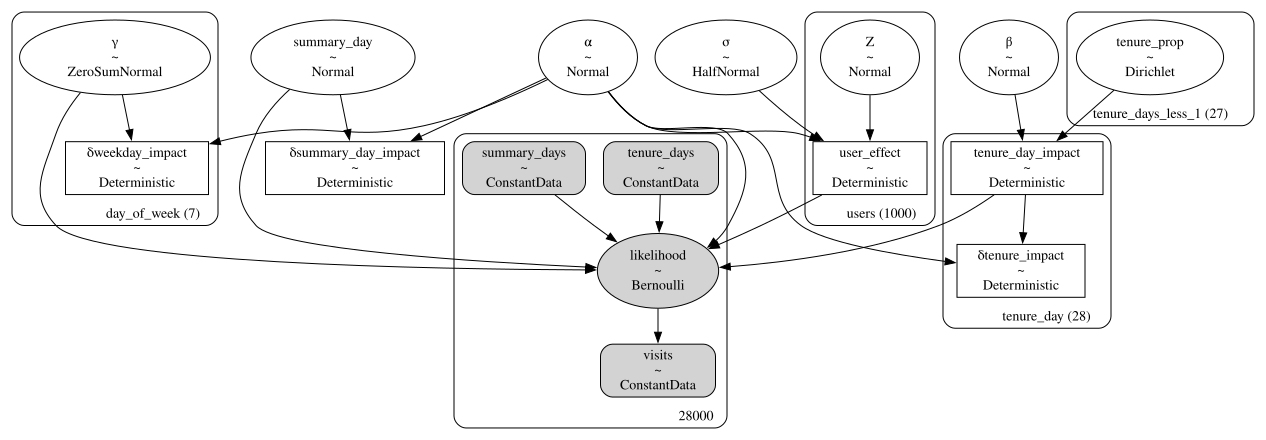

In [ ]:
user_idx, user_list = pd.factorize(activity['user_id'])
day_of_week_idx, days_of_week = pd.factorize(activity['day_of_week'])

with pm.Model(coords={
    'day_of_week': days_of_week,
    'tenure_day': np.arange(activity_parameters['tenure_length']),
    'tenure_days_less_1': np.arange(activity_parameters['tenure_length'])[1:],
    'users': user_list,
}) as hierarchical_model:
    
    summary_days = pm.ConstantData("summary_days", activity['is_summary_day'].values)
    tenure_days = pm.ConstantData("tenure_days", activity['tenure_day'].values.astype(int) - 1)
    visits = pm.ConstantData("visits", activity['visit'])
    
    W = pm.ZeroSumNormal("γ", sigma=2, dims='day_of_week')
    T = pm.Dirichlet("tenure_prop", a=dir_prior, dims='tenure_days_less_1')
    β = pm.Normal("β", mu = -2, sigma=1)
    cumT = pm.Deterministic(
        "tenure_day_impact", 
        β * pm.math.concatenate([np.zeros(1), T.cumsum(axis=0)], axis=0), 
        dims='tenure_day'
    )
    
    S = pm.Normal("summary_day", mu=0, sigma=1)
    α = pm.Normal("α", 0, 1)
    Z = pm.Normal("Z", 0, 1, dims='users')
    σ = pm.HalfNormal("σ", 2)

    user_effect = pm.Deterministic("user_effect", α + Z * σ, dims="users")

    inv_logit = α + S*summary_days + W[day_of_week_idx] + cumT[tenure_days] + user_effect[user_idx]
    pm.Bernoulli("likelihood", logit_p = inv_logit, observed = visits)

    #params of interest
    pm.Deterministic(
        "δtenure_impact", 
        (pm.math.invlogit(α + cumT) - pm.math.invlogit(α)),
        dims='tenure_day'
    )

    pm.Deterministic(
        "δweekday_impact",
        (pm.math.invlogit(α + W) - pm.math.invlogit(α)),
        dims='day_of_week'
    )

    pm.Deterministic(
        "δsummary_day_impact",
        (pm.math.invlogit(α + S) - pm.math.invlogit(α))        
    )

pm.model_to_graphviz(hierarchical_model)



In [ ]:
with hierarchical_model:
   h_trace = sample_blackjax_nuts()

Compiling...
Compilation time =  0:00:04.924362
Sampling...
Sampling time =  0:00:06.498666
Transforming variables...
Transformation time =  0:08:16.883390


In [ ]:
az.summary(
    h_trace, 
    var_names=['~tenure_day_impact', '~tenure_prop', '~δ', '~user_effect', '~Z'], 
    filter_vars='regex'
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
β,-1.598,0.093,-1.773,-1.426,0.002,0.001,2409.0,2440.0,1.00
summary_day,0.274,0.064,0.157,0.393,0.001,0.001,2643.0,3020.0,1.00
α,-0.099,0.050,-0.189,-0.002,0.002,0.001,770.0,1656.0,1.00
γ[Sat],-0.300,0.053,-0.397,-0.201,0.001,0.001,2723.0,2851.0,1.00
γ[Sun],-0.292,0.041,-0.367,-0.213,0.001,0.000,4565.0,2693.0,1.00
γ[Mon],0.373,0.041,0.298,0.449,0.001,0.000,4546.0,2139.0,1.00
γ[Tue],0.304,0.039,0.235,0.381,0.001,0.000,3727.0,2653.0,1.00
γ[Wed],0.024,0.038,-0.049,0.094,0.001,0.001,4792.0,2975.0,1.00
γ[Thu],-0.090,0.040,-0.167,-0.014,0.001,0.000,4938.0,2642.0,1.00
γ[Fri],-0.019,0.040,-0.092,0.060,0.001,0.001,5066.0,2451.0,1.00


In [ ]:
c1 = compare_tenure_effects(h_trace, activity_parameters)
c2 = compare_weekday_effects(h_trace, activity_parameters)

c1 | c2

alt.HConcatChart(...)

In [ ]:
user_effects = az.summary(h_trace, var_names=['user_effect'])
user_effects['true_effect'] = users['intrinsic_motivation'].values

In [ ]:
user_effects['mean'] = h_trace['posterior']['user_effect'].mean(dim=['chain', 'draw']).to_numpy()

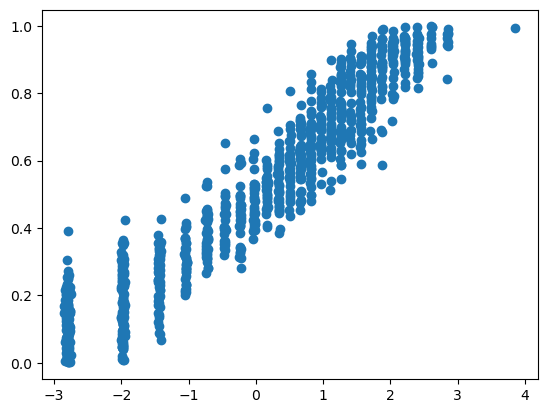

In [ ]:
plt.scatter(user_effects['mean'], user_effects['true_effect'])

In [ ]:
alt.Chart(user_effects).mark_point().encode(x='mean', y='true_effect')

alt.Chart(...)